# Проект: Исследование стартапов

## Введение

В рамках данного проекта проводится исследование на основе инвестиционных данных о финансировании компаний, и данных о сотрудниках этих компаний. Основная задача заключается в подготовке датасета, проверке его на соответствие здравому смыслу и ответах на ключевые вопросы, необходимых для разработки модели бизнеса, связанного с предоставлением льготных займов стартапам. 
<br><br>
В рамках данного проекта необходимо:
- Проверить качество данных, устранить возможные искажения и подготовить датасет для дальнейшего анализа.
- Определить, по каким столбцам можно объединять данные из разных таблиц, чтобы обеспечить целостность и релевантность информации.
- Оценить достоверность данных о сотрудниках стартапов и их образовании.
- Исследовать значение сделок с покупкой стартапов за 0 или 1 доллар, чтобы понять их природу и влияние на общую картину.
- Проанализировать зависимость цены покупки стартапа от его категории и количества раундов финансирования перед сделкой.
- Разработать методику расчёта ключевых численных показателей, таких как стоимость сделок, динамика инвестиций и другие метрики.
- Визуализировать полученные данные для наглядного представления результатов.

## Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* degrees.csv
* education.csv
* fund.csv
* investment.csv
* people.csv

### Вывод общей информации, исправление названия столбцов и типов данных

In [5]:
!pip install phik -q
!pip install missingno -q
#!pip install pandas== 1.2.4
#!pip install numpy== 1.20.1
#!pip install matplotlib== 3.3.4
#!pip install seaborn== 0.11.1

import phik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from phik import phik_matrix


* Загрузка всех данных:

In [7]:
a_df = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
cr_df = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
deg_df = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')
edu_df = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
fund_df = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
i_df = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')
ppl_df = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')

* Просмотр датасета acquisition.csv - a_df. <br>
Таблица содержит информацию о покупках одними компаниями других компаний:
- `id` — идентификатор покупки.
- `acquiring_company_id` — идентификатор покупающей компании.
- `acquired_company_id` — идентификатор покупаемой компании.
- `term_code` — варианты расчёта.
- `price_amount` — сумма сделки.
- `acquired_at` — дата сделки.

In [9]:
a_df.info()
display(a_df.head())
a_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
9402,10525,267859,285995,stock,222000000,2013-12-11
9403,10526,285493,286006,NaN,0,2013-12-09
9404,10527,223792,220208,NaN,26000000000,2007-07-03
9405,10528,227620,286176,cash,52400000,2013-12-12
9406,10529,53,92846,NaN,42600000,2013-12-12


Возможные варианты оплаты:

In [11]:
a_df['term_code'].unique()

array([nan, 'cash', 'stock', 'cash_and_stock'], dtype=object)

Названия столбцов нормальные, в столбце `acquired_at` тип данных следут привести к `datetime`. Столбцы без пропусков или с небольшим количеством пропусков, кроме столбца `term_code`, который заполнен только на ~20%.

In [13]:
a_df[a_df['price_amount'] < 1000]['price_amount'].value_counts()

price_amount
0      6931
1         3
200       1
373       1
49        1
11        1
60        1
Name: count, dtype: int64

In [14]:
a_df[(a_df['price_amount'] == 0)&(a_df['term_code'].isna() == False)]

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
6,12,5,230,cash,0,2007-07-01
7,14,318,314,cash,0,2006-10-01
13,20,377,100,cash,0,2005-05-29
15,23,307,306,cash,0,2007-08-07
21,30,541,542,cash,0,2006-01-01
...,...,...,...,...,...,...
9307,10419,166610,283108,cash,0,2013-10-01
9324,10439,41860,63392,cash,0,2013-12-03
9325,10440,39270,82805,stock,0,2013-12-03
9362,10480,64126,66009,stock,0,2011-05-01


Тем не менее для 6931 сделки сумма сделки указана равной 0, а также есть часть сделок, где стоимость сделок менее 1000$.

In [16]:
a_df['acquired_at'] = pd.to_datetime(a_df['acquired_at'])

* Просмотр датасета company_and_rounds:

In [18]:
cr_df.info()
display(cr_df.head())
cr_df[['name', 'funding  rounds','funding  total']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217471 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,name,funding rounds,funding total
0,Wetpaint,3.0,39750000.0
1,Wetpaint,3.0,39750000.0
2,Wetpaint,3.0,39750000.0
3,Flektor,0.0,0.0
4,There,0.0,0.0


In [19]:
cr_df.tail()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
217769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,0.0,1.0
217771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,1.0,0.0
217772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0
217773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,57063.0,284191.0,2013-12-04,venture,7000000.0,0.0,4.0,1.0,1.0


   Таблица `company_and_rounds` по-видимому является результатом слияния двух таблиц, первая из которых содержала данные про компании, а вторая - данные по раундам инвестиций. Из-за этого два очень похожих названия столбца (`company  ID` и `company  id`). Названия соответствуют содержанию столбцов, но содержат пробелы. На всякий случай также переименовываю столбец `company ID` на `company_id_left`

In [21]:
cr_df.columns = cr_df.columns.str.replace(r'\s+','_', regex = True)
cr_df.columns = cr_df.columns.str.replace('ID','id_left', regex = True)

print(cr_df.columns)

Index(['company_id_left', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
       'raised_amount', 'pre_money_valuation', 'participants',
       'is_first_round', 'is_last_round'],
      dtype='object')


Данные в столбцах `founded_at`, `funded_at` и `closed_at` необходимо привести к типу datetime. В остальных случаях тип данных соответствует содержанию столбцов.

In [23]:
cr_df['founded_at'] = pd.to_datetime(cr_df['founded_at'])
cr_df['funded_at'] = pd.to_datetime(cr_df['funded_at'])
cr_df['closed_at'] = pd.to_datetime(cr_df['closed_at'])

Данные с датами приводим к типу данных 'datetime'

* Датасеты degrees, education и fund:

In [26]:
deg_df.info()
display(deg_df.head())
deg_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


,id,object_id,degree_type,subject
109605,109606,p:268589,CPA,NaN
109606,109607,p:268527,MS & BS,Engineering
109607,109608,p:268527,PhD,Engineering
109608,109609,p:268528,B.S.,Electrical Engineering
109609,109610,p:268528,J.D.,NaN


In [27]:
edu_df.info()
display(edu_df.head())
edu_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


,id,person_id,instituition,graduated_at
109605,109606,268589,American Institute of Certtified Public Accoun...,NaN
109606,109607,268527,South China University of Technology,NaN
109607,109608,268527,Clarkson University,NaN
109608,109609,268528,Colorado State University,NaN
109609,109610,268528,University of San Diego School of Law,NaN


`object_id` и `person_id` оба являются идентификатором человека, но не совпадают: `object_id` это `person_id` к которому в начале добавили 'p:'.

In [29]:
edu_df['graduated_at'] = pd.to_datetime(edu_df['graduated_at'])

In [30]:
fund_df.info()
display(fund_df.head())
fund_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11649 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
11647,9997,Axel Johnson,1920-01-01,axeljohnson.com,NaN,USA,1,1,0
11648,9998,Liberty City Ventures,2012-07-01,libertycityventures.com,LCVentures,USA,5,5,0
11649,9999,CalSTRS,1913-07-01,calstrs.com,CalSTRS,USA,1,1,0
11650,11555,Haystack,2013-01-01,network.com::haystack_fund,haystack_fund,NaN,5,5,0
11651,2553,fbFund,NaN,developers.socialnet.com::fbfund.php,fbFund,NaN,23,21,2


* Датасеты investment и people:

In [32]:
i_df.info()
display(i_df.head(), i_df.tail())
i_df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


,id,funding_round_id,company_id,fund_id
61398,61399,57926,15847,173
61399,61400,57926,15847,1290
61400,61401,57926,15847,73
61401,61402,57942,70841,15098
61402,61403,57948,211890,2101


id                  61403
funding_round_id    27679
company_id          17991
fund_id              7671
dtype: int64

In [33]:
ppl_df.info()
display(ppl_df.head())
ppl_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


,id,first_name,last_name,company_id,network_username
226704,99999,Ramon,Peypoch,NaN,NaN
226705,174088,Dr. Ray,Woods,188200.0,network
226706,118386,Ricardo,Durand,143419.0,itechsocialnet
226707,175827,mahesh,kumar,NaN,socialnethubs
226708,178190,Alex,Smith,NaN,esocialnetlike


Данные в датасетах соответвуют названиям, типы данных не требуют изменений.

### Анализ пропусков и дубликатов

Данные по сделкам, датасет a_df:

In [37]:
a_df.isna().sum()

id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64

In [38]:
a_df.isna().mean()

id                      0.000000
acquiring_company_id    0.000000
acquired_company_id     0.000000
term_code               0.805358
price_amount            0.000000
acquired_at             0.003083
dtype: float64

В данных для небольшого количества сделок (29) отутствует информация о дате сделки, и для ~80,5% сделок не указан тип рассчета. Пропуски оставляю без изменений, чтобы не удалять ценную информацию и не заполнять значениями, которые впоследствии могут усложнить расчеты.

Пропуски в датасете компаний и раундов их финансирования:

In [41]:
cr_df.isna().sum()

company_id_left           302
name                      303
category_code           73888
status                    302
founded_at             107818
closed_at              214325
domain                  70615
network_username       122240
country_code           109167
investment_rounds         302
funding_rounds            302
funding_total             302
milestones                302
funding_round_id       164846
company_id             164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64

<Axes: >

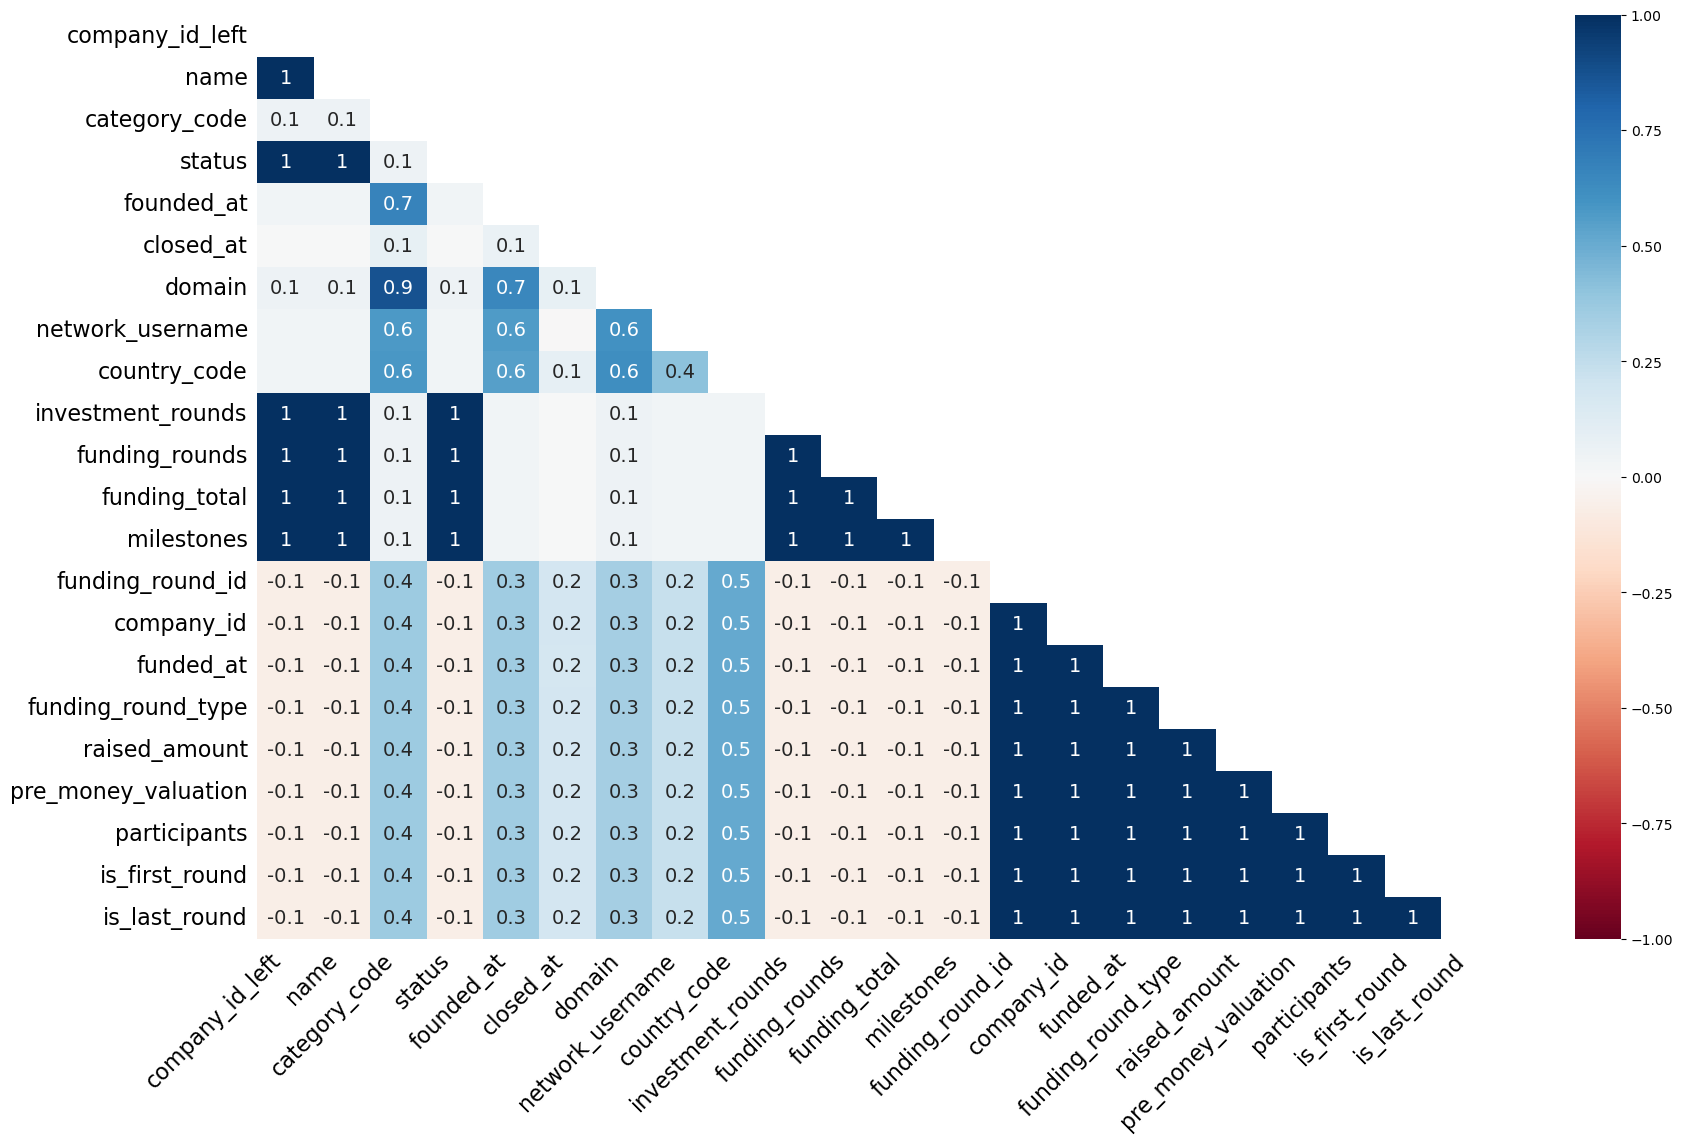

In [42]:
msno.heatmap(cr_df)

Датасет по пропускам как будто состоит из двух объединенных датасетов:  датасет состоящий из первых 13 колонок `cr_df`, внутри которого наличие пропусков сильно коррелирует. Эта часть датасета описывают информацию о компаниях. Вторая часть датасета, включающая последние 8 столбцов `cr_df`, содержит информацию о раундах финансирования и пропуски в этих столбцах внутри объединенного датасета `cr_df` полностью совпадают. Разделяю большой датасет на два отдельных датасета.

In [44]:
c_df = cr_df[cr_df.columns[:13]]
c_df = c_df.reset_index(drop = True)
c_df.info()
cdf_len_old = c_df.shape[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id_left    217472 non-null  float64       
 1   name               217471 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  float64       
 10  funding_rounds     217472 non-null  float64       
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)


In [45]:
c_df = c_df.drop_duplicates()
c_df = c_df.dropna(how = 'all')
display(f'Удалено {cdf_len_old - c_df.shape[0]} дубликатов в датасете c_df')
c_df.info()

'Удалено 21221 дубликатов в датасете c_df'

<class 'pandas.core.frame.DataFrame'>
Index: 196553 entries, 0 to 217469
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id_left    196553 non-null  float64       
 1   name               196552 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   object        
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memor

In [46]:
r_df = cr_df[cr_df.columns[13:]]
r_df = r_df.reset_index(drop = True)
r_df.info()
rdf_len_old = r_df.shape[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   company_id           52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 15.0+ MB


In [47]:
r_df.duplicated().sum()
r_df = r_df.drop_duplicates()
r_df = r_df.dropna(how = 'all')
display(f'Удалено {rdf_len_old - r_df.shape[0]} дубликатов в датасете r_df')
r_df.info()

'Удалено 164846 дубликатов в датасете r_df'

<class 'pandas.core.frame.DataFrame'>
Index: 52928 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   company_id           52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 4.0+ MB


In [48]:
c_df.isna().mean()

company_id_left      0.000000
name                 0.000005
category_code        0.373268
status               0.000000
founded_at           0.535866
closed_at            0.986670
domain               0.356179
network_username     0.589978
country_code         0.552334
investment_rounds    0.000000
funding_rounds       0.000000
funding_total        0.000000
milestones           0.000000
dtype: float64

In [49]:
r_df.isna().mean()

funding_round_id       0.000000
company_id             0.000000
funded_at              0.004686
funding_round_type     0.000000
raised_amount          0.000000
pre_money_valuation    0.000000
participants           0.000000
is_first_round         0.000000
is_last_round          0.000000
dtype: float64

  В результате такого разделения получили два датасета, первый - `c_df` содержит информацию о компаниях и содержит пропуски только в некоторых столбцах : `category_code`(37% пропусков),`founded_at` (~ 54% пропусков), `closed_at` (~ 98,7 % пропусков, что связано с тем, что в таблице почти все компании все еще действующие), `domain` (~36% пропусков), `network_username` (59%) и `country_code` (55%). Второй датасет с информацие о раундах финансирования имеет только небольшой процент пропусков в столбце с  датй финансирования (`funded_at, ~0.5%`). В целом предоставленных данных достаточно, чтобы провести анализ об инвестировании в компании. Пропуски в данных оставляю необработанными, чтобы не терять большое количество данных и для удобства дальнейших вычислений..

- Пропуски в остальных датасетах:
датасеты по образованию сотрудников

In [52]:
deg_df.isna().mean()

id             0.000000
object_id      0.000000
degree_type    0.102372
subject        0.258298
dtype: float64

In [53]:
deg_df['degree_type'].nunique()

7147

In [54]:
deg_df['degree_type'] = deg_df['degree_type'].str.lower()
deg_df['degree_type'].nunique()

6750

In [55]:
print('Уникальных значений специальности: ', deg_df['subject'].nunique())

Уникальных значений специальности:  20050


In [56]:
deg_df['subject'] = deg_df['subject'].str.lower()
print('Уникальных значений специальности после нормализации: ', deg_df['subject'].nunique())

Уникальных значений специальности после нормализации:  19182


In [57]:
deg_df[(deg_df['degree_type'].isna() == False) & (deg_df['degree_type'].str.contains('bachelor'))]

,id,object_id,degree_type,subject
349,350,p:8059,bachelors (first class honours),computer science
625,626,p:9768,bachelor of commerce (honors) gr,business economics
678,679,p:9970,bachelors of mathematics,mathematics
688,689,p:9786,bachelor of electrical engineeri,electrical engineering
1003,1004,p:7234,bachelor of fine arts,NaN
...,...,...,...,...
109541,109542,p:268488,bachelor of fine arts (bfa),theatre/theater
109542,109543,p:268488,bachelor of arts (ba),theatre/theater
109550,109551,p:268428,bachelor of arts,NaN
109582,109583,p:268514,bachelors,economics


Нормализация данных о степени и отрасли уменьшило количество уникальных значений в столбцах, но данные по степеням содержат много неявно дублирующихся значений (сокращения, бакалавриат в разных отраслях и т.д.).Например строки с id - 109542 и 109543 содержат информацию об одном и том  же человеке, для которого немного по-разному указана степень. Фактически, это дублирующаяся строка. На данном этапе оставляю эти данные, так как быстрый стандартный метод тут не поможет, но если потребуется анализ корреляций с степенью образования, потребуется дополнительная обработка этих данных, чтобы уменьшить количество дубликатов. Пропуски данных со степенью и отраслью оставляю без изменений. Привожу id к числовому виду, чтобы возможно было соединять данные с другими датасетами с информацией о сотрудниках.

In [59]:
deg_df['object_id'] = deg_df['object_id'].str.replace('p:','').astype(float)
deg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           109610 non-null  int64  
 1   object_id    109610 non-null  float64
 2   degree_type  98389 non-null   object 
 3   subject      81298 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ MB


In [60]:
ppl_df.isna().mean()

id                  0.000000
first_name          0.000040
last_name           0.000018
company_id          0.847315
network_username    0.828560
dtype: float64

In [61]:
display('Количество строк с дублирующимися именами: ', ppl_df[ppl_df.duplicated(subset = ['first_name', 'last_name'])].count())
display(ppl_df[ppl_df.duplicated(subset = ['first_name', 'last_name'], keep = False)].sort_values(by='last_name', ascending = False).head(14))

'Количество строк с дублирующимися именами: '

id                  14053
first_name          14050
last_name           14050
company_id           2238
network_username     2542
dtype: int64

,id,first_name,last_name,company_id,network_username
13173,116555,x,xx,NaN,NaN
1752,102132,x,xx,NaN,NaN
200042,70539,jon,willison,NaN,mlsbyowner64gm
199747,70249,jon,willison,NaN,listflatefeegm
80368,193175,Ruel,williamson,NaN,NaN
80377,193183,Ruel,williamson,NaN,NaN
80386,193191,Ruel,williamson,NaN,NaN
114305,226852,John,wakefiwld,NaN,NaN
113313,225881,John,wakefiwld,NaN,NaN
109695,22245,Per,von Zelowitz,NaN,NaN


In [62]:
ppl_df.nunique()

id                  226708
first_name           28421
last_name           107771
company_id           22922
network_username     38421
dtype: int64

In [63]:
ppl_df['first_name'] = ppl_df['first_name'].str.lower()
ppl_df['last_name'] = ppl_df['last_name'].str.lower()
print('Уникальных значений имен после нормализации: ', ppl_df['first_name'].nunique())
print('Уникальных значений фамилий после нормализации: ', ppl_df['last_name'].nunique())
print('Количество строк с дублирующимися именами после нормализации: ', ppl_df[ppl_df.duplicated(subset = ['first_name', 'last_name'])].shape[0])

Уникальных значений имен после нормализации:  26719
Уникальных значений фамилий после нормализации:  105539
Количество строк с дублирующимися именами после нормализации:  14410


Датасет с информацией о сотрудниках (`ppl_df`, исходная таблица `people`) имеет более 80% пропущенных значений  в столбцах с идентификатором компании и ником в соц.сетях. Таблица имеет более 14000 дублирующихся строк по паре 'имя - фамилия'. То есть для некоторых сотрудников есть по несколько записей с различными id, и в некоторых случаях, даже с разными значениями, указанными в столбце `network_username`. Пока данные оставляю без изменений, т.к. неизвестно, какой именно id сотрудника мог использоваться в других таблицах с информацией об образовании сотрудников.

In [65]:
edu_df.isna().mean()

id              0.000000
person_id       0.000000
instituition    0.000502
graduated_at    0.470359
dtype: float64

In [66]:
edu_df[edu_df.duplicated(subset = ['person_id', 'instituition', 'graduated_at'], keep = False)]

,id,person_id,instituition,graduated_at
34,35,6614,University of Texas,1998-01-01
35,36,6614,University of Texas,1998-01-01
46,47,2216,Stanford University,NaT
47,48,2216,Stanford University,NaT
53,54,2371,"University of California, Berkeley",NaT
...,...,...,...,...
109589,109590,268517,University of Massachusetts,NaT
109595,109596,268520,Waseda University,NaT
109596,109597,268520,Waseda University,NaT
109599,109600,158143,Case Western Reserve University,NaT


Данные содержат 8000 дублирующихся строк, по всем столбцам кроме id, дубликаты убираю.

In [68]:
edu_df = edu_df.drop_duplicates(subset = ['person_id', 'instituition', 'graduated_at'])
edu_df = edu_df.reset_index(drop = 'True')
display(edu_df.nunique())
edu_df.isna().mean()

id              105472
person_id        68451
instituition     21067
graduated_at        71
dtype: int64

id              0.000000
person_id       0.000000
instituition    0.000503
graduated_at    0.458235
dtype: float64

In [69]:
edu_df.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


Датасет с информацией об образовании сотрудников почти не содержит пропусков в информации о названии учебного заведения, но в 47% данных нет информации о годе выпуска из заведения. Пропуски оставляю без изменений. 

На первом этапе были проанализированы содержание представленных датасетов, промежуточные выводы после первичного анализа:
- названия столбцов во всех датасетах приведены к snake_case, одно из дублирующихсяся названий `company_id` в таблице `company_and_rounds` заменено на `company_id_left`
- во всех таблицах есть столбцы с пропусками в данных в разной степени. Все пропущенные значения оставила без изменений, чтобы не усложнять расчеты на следующих шагах и не удалять большую часть данных.
- Характер пропусков в таблице `cr_df` (`company_and_rounds`) позволил выделить из большой таблицы две отдельные таблицы `c_df` с информацией о компаниях, и `r_df` c информацией о раундах финансирования. Такое разделение позволило уменьшить количество пропусков и оптимизировать работу с информацией.
- в таблице `edu_df`с информацией об образовании сотрудников были удалены 8001 строка с дублирующимися значениями
- в таблице `ppl_df` с информацией о сотрудниках обнаружены неявно дублирующиеся записи, относящиеся к одному и тому же человеку, но с разными значениями id. Эти данные оставлены без изменений.
- в таблице `deg_df` была сделана нормализация записей в столбцах `degree_type` и `subject`, что уменьшило количество неявно дублирующихся значений, однако для исследований связанных с наличием ученых степеней потребуется дополнительная работа с неявными дубликатами в этом датасете. Также значения `object_id` были приведены к виду, аналогичному в связанных датасетах `ppl_df` и `edu_df`.


## Предобработка данных, предварительное исследование


### Динамика изменения финансирования по годам

На основе датасета `company_and_rounds.csv`построены:

* Сводная таблица pivot_cr по годам, в которой на основании столбца `raised_amount` для каждого года указан:

  * типичный размер средств, выделяемый в рамках одного раунда;
  * общее количество раундов финансирования за этот год.

* В таблице pivot_cr_50 данные отфильтрованы только для тех лет, для которых есть информация о более чем 50 раундах финансирования.

* На основе получившейся таблицы построен график, который  отражает динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

In [74]:
pd.set_option('display.max_columns', 30)
#display(cr_df[(cr_df['investment_rounds'] > 0)&(cr_df['funding_rounds'] > 0)].head())

In [75]:
cr_df['funded_year'] = cr_df['funded_at'].dt.year
pivot_cr = pd.pivot_table(cr_df[(cr_df['raised_amount']>0)], 
                          index = 'funded_year', values = 'raised_amount', aggfunc = ['median', 'count'])
display(pivot_cr.style.format("{:.0f}"))

,median,count
,raised_amount,raised_amount
funded_year,,
1960.000000,1330515,4
1984.000000,70500,2
1987.000000,2500000,1
1989.000000,15000,1
1990.000000,1000000,1
1992.000000,2000000,1
1993.000000,125000,1
1994.000000,6700000,2


In [76]:
pivot_cr_50 = pivot_cr[pivot_cr[('count','raised_amount')] > 50]
pivot_cr_50 = pivot_cr_50.reset_index()
pivot_cr_50.columns = ['year', 'median_amount', 'rounds_count']
display (pivot_cr_50.style.format("{:.0f}"))

,year,median_amount,rounds_count
0,1999,3000000,60
1,2000,5866800,104
2,2001,5481060,74
3,2002,5000000,96
4,2003,4500000,133
5,2004,6000000,252
6,2005,6000000,1550
7,2006,5325000,2290
8,2007,4880000,2927
9,2008,4368150,3326


Text(0, 0.5, 'Размер финансирования, млн.у.е.')

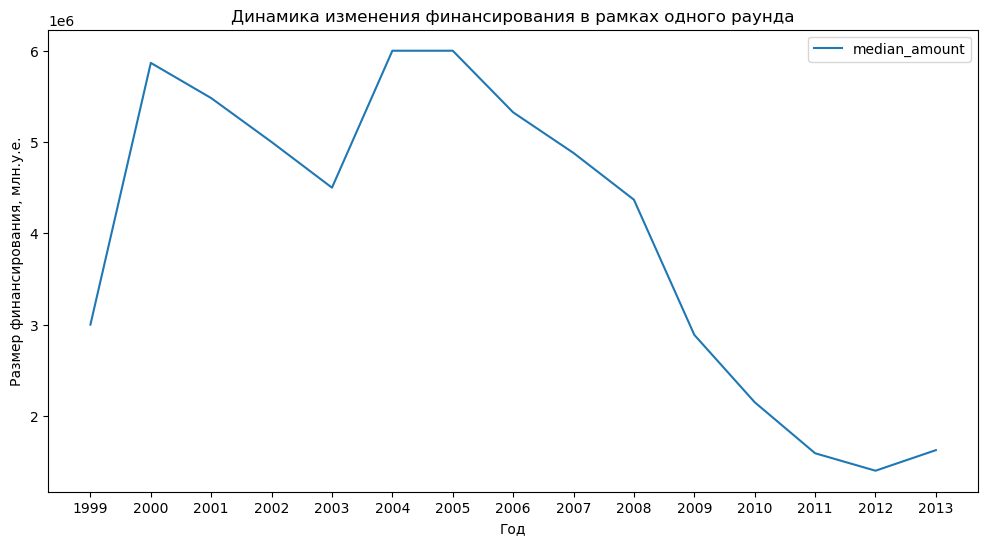

In [77]:
pivot_cr_50.plot(kind = 'line', x = 'year', y = 'median_amount', figsize = (12,6), xticks = pivot_cr_50['year'])
plt.title('Динамика изменения финансирования в рамках одного раунда')
plt.xlabel('Год')
plt.ylabel('Размер финансирования, млн.у.е.')

Максимальное значение финансирования в раунде было в 2004 и 2005 годах, тогда половина стартапов получала не менее 6 млн. у.е. за раунд. После длительного снижения финансирования в 2005-2012 годах в 2013 году значения финансирования одного раунда снова начали расти. Количество профинансированных раундов стабильно росло начиная с 2001 года и в 2013 году количество профинансированных раундов также стало больше, по сравнению с 2012 г.


### Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

In [80]:
ppl_df.head()

,id,first_name,last_name,company_id,network_username
0,10,mark,zuckerberg,5.0,NaN
1,100,peter,lester,27.0,NaN
2,1000,dr. steven,e. saunders,292.0,NaN
3,10000,neil,capel,2526.0,NaN
4,100000,sue,pilsch,NaN,NaN


In [81]:
ppl_df['company_id'].nunique()

22922

In [82]:
edu_df.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


Датасет с образованием может содержать для сотрудника несколько записей, чтобы оценить полноту данных в зависимости от количества сотрудников в компании сначала решила изменить датасет таким образом, чтобы для каждого сотрудника была только одна запись, указывающая на наличие записей об образовании:

In [84]:
edu_df_comp = edu_df.groupby('person_id').agg({'instituition':'count', 'graduated_at':'count'})
edu_df_comp = edu_df_comp.reset_index()
edu_df_comp= edu_df_comp.rename(columns = {'instituition':'instit_records', 
                                           'graduated_at':'grad_date_records'})
edu_df_comp.head()

,person_id,instit_records,grad_date_records
0,2,1,1
1,3,2,0
2,5,2,2
3,6,2,1
4,7,1,1


In [85]:
pe_df = ppl_df.merge(edu_df_comp, how = 'left', left_on='id', right_on = 'person_id')
pe_df = pe_df.drop(labels = "person_id", axis = 1)
pe_df.head()

,id,first_name,last_name,company_id,network_username,instit_records,grad_date_records
0,10,mark,zuckerberg,5.0,NaN,1.0,0.0
1,100,peter,lester,27.0,NaN,NaN,NaN
2,1000,dr. steven,e. saunders,292.0,NaN,NaN,NaN
3,10000,neil,capel,2526.0,NaN,NaN,NaN
4,100000,sue,pilsch,NaN,NaN,NaN,NaN


In [86]:
pe_grouped_df = pe_df.groupby('company_id').agg({'id': 'count', 
                                                 'instit_records': lambda x: (x>0).sum(),
                                                 'grad_date_records': lambda x: (x>0).sum()})
pe_grouped_df = pe_grouped_df.reset_index()
pe_grouped_df.head()
pe_grouped_df.describe().round(1)

,company_id,id,instit_records,grad_date_records
count,22922.0,22922.0,22922.0,22922.0
mean,102688.5,1.5,0.8,0.6
std,84842.9,2.8,2.0,1.4
min,1.0,1.0,0.0,0.0
25%,28844.5,1.0,0.0,0.0
50%,70878.5,1.0,1.0,0.0
75%,174083.5,1.0,1.0,1.0
max,286091.0,244.0,168.0,115.0


Text(0.5, 1.0, 'Представленность информации об образовании сотрудников')

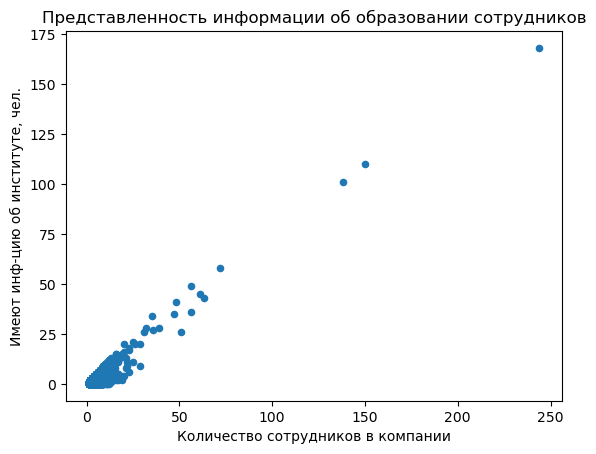

In [87]:
pe_grouped_df.plot(kind = 'scatter', x = 'id', y = 'instit_records')
plt.xlabel('Количество сотрудников в компании')
plt.ylabel('Имеют инф-цию об институте, чел.')
plt.title('Представленность информации об образовании сотрудников')

Датасет pe_grouped_df содержит информацию о том, насколько полна информация о сотрудниках. Всего информация представлена для 22922 компаний. При этом 75% компаний содержат информацию не более чем об 1 сотруднике компании. Самая крупная компания имеет информацию о 244 сотрудниках. Решила поделить компании по количеству сотрудников на следующие группы: 
- 2 или меньше, маленькие, самая большая группа   
- 3-10 человек, небольшие стартапы
- 11-25 человек, средняя компания, развивающийся стартап
- 26-50, крупная компания
- более 50 человек - очень крупные, их совсем немного

In [89]:
pe_grouped_df['comp_size'] = pd.cut(pe_grouped_df['id'], bins = [0, 2, 10, 25, 50, 400], 
                                    labels = ['xs', 's', 'm', 'l', 'xl'])
size_data_fullness = pe_grouped_df.groupby('comp_size').agg({
    'instit_records': lambda x: x.sum()/(pe_grouped_df.loc[x.index, 'id']).sum(), 
    'grad_date_records': lambda x: x.sum()/(pe_grouped_df.loc[x.index, 'id']).sum()})
display(size_data_fullness.round(2))

C:\Users\Деси\AppData\Local\Temp\ipykernel_5704\3161128886.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_data_fullness = pe_grouped_df.groupby('comp_size').agg({


,instit_records,grad_date_records
comp_size,,
xs,0.54,0.43
s,0.49,0.34
m,0.54,0.31
l,0.76,0.51
xl,0.71,0.41


В группе компаний с маленьким - средним  количеством сотрудников данные по высшему учебному заведению заполнены на ~49-54%. Информация о дате окончания заполнена хуже - в компаниях с количеством сотрудников от 11 до 25 дата окончания ВУЗа указана для 31% сотрудников. Для более маленьких компаний это значение немного выше - 34-43% заполненных данных. Для крупных и очень крупных компаний доля сотрудников для которых нет информации по образованию меньше, данные по ВУЗам зполнены более чем для 70% сотрудников, а год окончания в 41-51% в случае в зависимости от размера компании. <br><br>
В разделе `1.2 Анализ пропусков и дубликатов` было показано, что таблица `degrees` (deg_df) содержит информацию об ученых степенях сотрудников, при этом для каждого сотрудника может содержаться несколько строк об образовании и некоторые строки содержат неявные дубликаты. 
- Проверим, несет ли датасет `degree` дополнительную информацию, то есть, найдем список сотрудников, для которых указана информация о наличии степени, но нет информации про образование:

In [91]:
deg_df_comp = deg_df.groupby('object_id')[['degree_type', 'subject']].count()
deg_df_comp = deg_df_comp.reset_index()
deg_df_comp = deg_df_comp.rename(columns = {'degree_type':'deg_records', 'subject':'sbj_records'})

added_info = pd.merge(pe_df[(pe_df['instit_records'] + pe_df['grad_date_records'])>0], #сотрудники для которых есть записи о ВУЗе или годе окончания
                     deg_df_comp[(deg_df_comp['deg_records'] + deg_df_comp['sbj_records']) > 0], #сотрудники для которых есть записи о степени или области
                     how = 'right', left_on = 'id', right_on = 'object_id')
added_info[(added_info['instit_records'].isna() == True) & (added_info['grad_date_records'].isna()== True)].count()



id                     0
first_name             0
last_name              0
company_id             0
network_username       0
instit_records         0
grad_date_records      0
object_id            371
deg_records          371
sbj_records          371
dtype: int64

Как оказалось, есть 371 таких id сотрудников, для которых имеется информация о степенях, но для этих строк не указани ни ВУЗ, ни "имя-фамилия". Данные id не встречаются среди сотрудников ни для одной компании. Т.е. добавление датасета `degree` (deg_df) в целом не добавит информации, к датасетам `people` и `education` (pe_df) которая помогла бы лучше оценить полноту образования сотрудников среди компаний разного размера.

### Объединение таблиц с информацией о людях и компаниях
Столбец `network_username` встречается в трех датасетах: `company_and_rounds`, `people` и `fund`. 
- Во-первых, смотрим какой процент данных и сколько строк в абсолютном значении в таблицах имеют значения `network_username`:

In [94]:
print(f"company and rounds 'network_username': всего записей -  {cr_df['network_username'].count()}, доля заполненных строк - {(1 - cr_df['network_username'].isna().mean()).round(2)}")

company and rounds 'network_username': всего записей -  95534, доля заполненных строк - 0.44


In [95]:
print(f"people 'network_username': всего записей -  {ppl_df['network_username'].count()}, доля заполненных строк - {(1 - ppl_df['network_username'].isna().mean()).round(2)}")

people 'network_username': всего записей -  38867, доля заполненных строк - 0.17


In [96]:
print(f"fund 'network_username': всего записей -  {fund_df['network_username'].count()}, доля заполненных строк - {(1 - fund_df['network_username'].isna().mean()).round(2)}")

fund 'network_username': всего записей -  2149, доля заполненных строк - 0.18


 Доля заполненных строк в столбце `network_username` в двух последних датасетах совсем невысокая, это говорит в пользу того, что данный столбец  уже плохо подходит для объединения.  
 - Проверим, насколько совпадают значения в данных по `network_username` в разных датасетах:

In [98]:
print(f" Уникальных ников: cr_df - {cr_df['network_username'].nunique()}, \
ppl_df - {ppl_df['network_username'].nunique()}, \
fund_df - {fund_df['network_username'].nunique()}")

 Уникальных ников: cr_df - 79571, ppl_df - 38421, fund_df - 2098


In [99]:
cr_nu = set(cr_df['network_username'].unique())
ppl_nu = set(ppl_df['network_username'].unique())
fund_nu = set(fund_df['network_username'].unique())
cr_ppl_nu = cr_nu.intersection(ppl_nu)
cr_fund_nu = cr_nu.intersection(fund_nu)
ppl_fund_nu = ppl_nu.intersection(fund_nu)

print("Пересекающихся значений network_username между датасетами company_and_rounds и people: ", len(cr_ppl_nu))
print("Пересекающихся значений network_username между датасетами company_and_rounds и fund: ", len(cr_fund_nu))
print("Пересекающихся значений network_username между датасетами people и fund: ", len(ppl_fund_nu))

Пересекающихся значений network_username между датасетами company_and_rounds и people:  2200
Пересекающихся значений network_username между датасетами company_and_rounds и fund:  71
Пересекающихся значений network_username между датасетами people и fund:  80


Среди значений network_username общих данных для пар датасетов единицы процентов, это значит, что данный столбец не подходит для объединения датасетов. Самое большое количество пересечений между данными о компаниях и людях - 2200 совпадений. 


### Проблемный датасет 'company_and_rounds' и причина возникновения пропусков

В пункте 1.2. при анализе пропусков в датасетах уже разделила датасет `company_and_rounds` (cr_df) на два `company` (c_df) и `rounds` (r_df). Там же в разделе в разделенных датасетах были удалены строки, в которых все значения после разделения оказались незаполненными (NaN) и дублирующиеся строки. В результате были получены два новых датасета, с которыми удобнее проводить отдельно анализ по количеству сделок 
(`c_df`) и, отдельно, по размерам финансирования (`r_df`).

In [102]:
c_df.nunique()

company_id_left      196553
name                 196505
category_code            42
status                    4
founded_at             6156
closed_at               925
domain               125498
network_username      79571
country_code            175
investment_rounds        42
funding_rounds           16
funding_total          9483
milestones               10
dtype: int64

In [103]:
r_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52928 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   company_id           52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  object        
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  float64       
 8   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 4.0+ MB


In [104]:
r_df.nunique()

funding_round_id       52928
company_id             31939
funded_at               3399
funding_round_type         9
raised_amount          10266
pre_money_valuation       27
participants              32
is_first_round             2
is_last_round              2
dtype: int64


## Исследовательский анализ объединённых таблиц



### Объединение и подготовка данных

Объединение данных для ответа на вопросы заказчика, которые касаются интересующих его компаний.
<br><br>
В качестве основы для объединённой таблицы использованы данные из "левой части" датасета `company_and_rounds.csv`, датасет c_df, несущий большую часть информации про компании. Из этого датасета отобраны компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. <br><br>
Затем датасет объединен с датасетом `acquisition` (a_df), с информацией о покупках компаний.

In [107]:
c_df_filtered = c_df[(c_df['funding_rounds'] > 0) | (c_df['investment_rounds'] > 0) | (c_df['status'] == 'acquired')] 

In [108]:
funded_c_df= pd.merge(c_df_filtered, a_df, how = 'left', left_on = 'company_id_left', right_on = 'acquired_company_id')
funded_c_df = funded_c_df.rename(columns = {'id':'deal_id'})
funded_c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40890 entries, 0 to 40889
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   company_id_left       40890 non-null  float64       
 1   name                  40890 non-null  object        
 2   category_code         35436 non-null  object        
 3   status                40890 non-null  object        
 4   founded_at            27911 non-null  datetime64[ns]
 5   closed_at             2128 non-null   datetime64[ns]
 6   domain                35883 non-null  object        
 7   network_username      20938 non-null  object        
 8   country_code          34858 non-null  object        
 9   investment_rounds     40890 non-null  float64       
 10  funding_rounds        40890 non-null  float64       
 11  funding_total         40890 non-null  float64       
 12  milestones            40890 non-null  float64       
 13  deal_id         

In [109]:
funded_c_df.head()

,company_id_left,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,deal_id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,NaN,NaN,NaN,NaN,NaN,NaT
1,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,1.0,11.0,10.0,NaN,20000000.0,2007-05-30
2,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,20.0,377.0,100.0,cash,0.0,2005-05-29
3,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0,1901.0,5.0,1001.0,cash_and_stock,47500000.0,2009-08-10
4,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0,3878.0,23054.0,10014.0,NaN,0.0,2010-09-30



### Анализ выбросов распределения общего финансирования компаний

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

In [111]:
funded_c_df['funding_total'].describe()/1000000

count       0.040890
mean       10.135586
std        56.412887
min         0.000000
25%         0.000000
50%         0.600000
75%         5.631320
max      5700.000000
Name: funding_total, dtype: float64

Text(0.5, 1.0, 'Распределение общего финансирования для компаний')

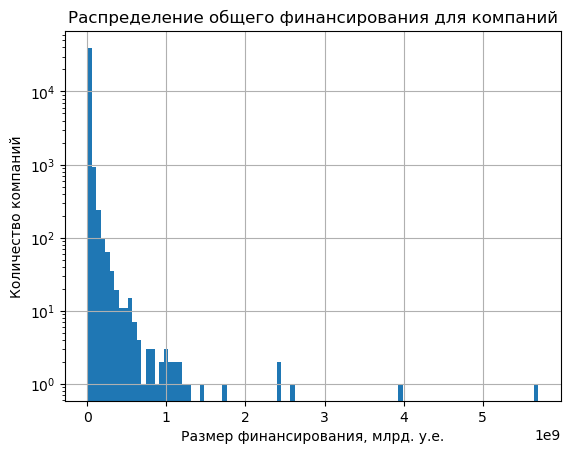

In [112]:
funded_c_df['funding_total'].hist(bins = 100, log = True)
plt.xlabel('Размер финансирования, млрд. у.е.')
plt.ylabel('Количество компаний')
plt.title('Распределение общего финансирования для компаний')

Text(0.5, 1.0, 'Распределение финансирования для компаний c funding_total < 1 000 000 у.е.')

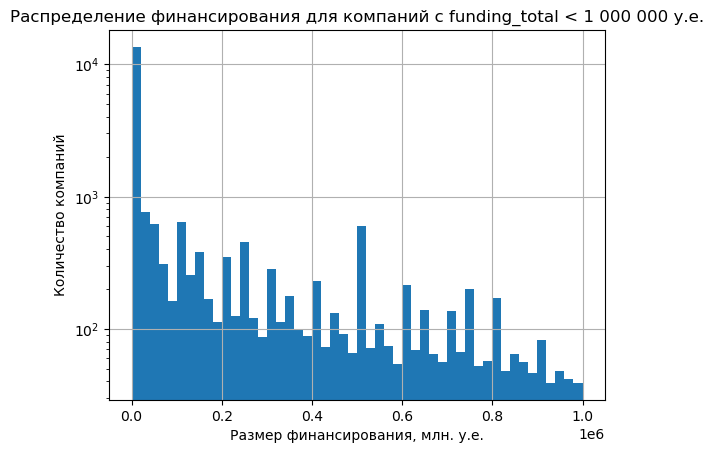

In [113]:
funded_c_df[funded_c_df['funding_total']<1000000]['funding_total'].hist(bins = 50, log = True)
plt.xlabel('Размер финансирования, млн. у.е.')
plt.ylabel('Количество компаний')
plt.title('Распределение финансирования для компаний c funding_total < 1 000 000 у.е.')

Среднее значение финансирования стартапов равно 10.14 млн., стандартное отклонение - 56.41 млн. Такое высокое значение стандартного отклонения указывает на сильный разброс данных. Медиана выборки равна 0.6, это значительно меньше среднего значения, это также указывает на асимметрию данных. <br><br> По-видимому, все дело в том, что данные содержат большое количество компаний, для которых финансирование указано равное нулю или близкое к минимальным значениям. Но при этом есть значительное количество компаний с очень большим финансированием, например, максимальное финансирование, которое получила компания - 5.7 млрд., что намного выше среднего значения финансирования. В результате в распределении значений наблюдается длинный правый "хвост" и статистические метрики не отражают реальные типичные значения финансирования. <br><br>
50% компаний имеют финансирование менее 600 000 у.е., а 75%  компаний менее 5.6 млн. у.е. Если рассмотреть как получали финансирования компании с общим финансированием меньше 1 млрд.у.е., в этом случае типичным размером финансирования можно назвать или небольшие суммы - 20 000, 40 000 и 100 000 у.е. или  500 000 у.е.: в области этих значений наблюдаются самые высокие пики на графике, соответсвующие наибольшему количеству профинансированных компаний. 


### Фильтрация аномальных данных

* Сначала была сделана фильтрация компаний, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

* Рассчитала аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total`.

In [116]:
o_companies_df = funded_c_df[ ((funded_c_df['price_amount'] == 0) | (funded_c_df['price_amount'] == 1))\
                             & (funded_c_df['funding_total'] > 0)]
o_companies_df.head()

,company_id_left,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,deal_id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
25,10054.0,Jumptap,mobile,acquired,2005-01-01,NaT,jumptap.com,jumptap,USA,0.0,7.0,121500000.0,3.0,9288.0,23283.0,10054.0,cash_and_stock,0.0,2013-08-13
63,101312.0,SideTour,web,acquired,2011-06-01,NaT,sidetour.com,sidetour,USA,0.0,3.0,4000000.0,2.0,9653.0,11391.0,101312.0,NaN,0.0,2013-09-18
66,101340.0,ChoicePass,enterprise,acquired,2011-07-01,NaT,choicepass.com,choicepass,USA,0.0,1.0,250000.0,1.0,7272.0,1972.0,101340.0,NaN,0.0,2012-06-18
67,10137.0,Producteev,software,acquired,2008-07-08,NaT,producteev.com,producteev,USA,0.0,3.0,1310000.0,2.0,8254.0,757.0,10137.0,cash_and_stock,0.0,2012-11-05
68,10139.0,TradeCard,enterprise,acquired,1999-01-01,NaT,tradecard.com,TradeCard,USA,0.0,2.0,44925000.0,1.0,9326.0,44008.0,10139.0,NaN,0.0,2013-04-01


In [117]:
q1 = o_companies_df['funding_total'].quantile(0.25)
q3 = o_companies_df['funding_total'].quantile(0.75)
iqr = q3-q1
low_threshold = q1 - iqr*1.5
high_threshold = q3 + iqr*1.5
print(f'Аналитические границы выбросов: верхняя = {high_threshold}, нижняя = {low_threshold}')
print("95-й процентиль: ", o_companies_df['funding_total'].quantile(0.95))
print("91-й процентиль: ", o_companies_df['funding_total'].quantile(0.91))
print("90-й процентиль: ", o_companies_df['funding_total'].quantile(0.90))
print("1-й процентиль: ", o_companies_df['funding_total'].quantile(0.01))

Аналитические границы выбросов: верхняя = 35750000.0, нижняя = -18250000.0
95-й процентиль:  51487499.99999996
91-й процентиль:  35894000.00000001
90-й процентиль:  33015809.999999996
1-й процентиль:  20000.0


Аналитически рассчитанная верхняя граница выбросов соответвует значению между 90 и 91-м процентилями. Если отсекать верхние выбросы по аналитически рассчитанной границе, получается, что отсекаются почти 10% данных, а рассчеты на такой усеченной выборке могут содержать сильные искажения и не соответвовать реальности. Поэтому лучше поднять границу выбросов хотя бы до 95-го процентиля, например. <br>
Нижняя граница выбросов, рассчитанная аналитически, имеет отрицательное значение. Такое значение вообще не имеет физического смысла, т.к. финансирование может иметь только неотрицательное значение. Плюс ко всему, такая нижняя граница не отсекает компании с финансированием равным нулю, которые также мешают анализу. В качестве нижней границы выбросов, я бы выбрала условие, что финансирование должно иметь положительное значение (">0"). 


### Цены стартапов по категориям


In [120]:
display('Количество категорий: ', funded_c_df['category_code'].nunique())
pd.set_option('display.float_format', '{:.2f}'.format)
display('Статистика стоимости компании, по всем компаниям:', funded_c_df['price_amount'].describe())
display ('Статистика стоимости компании, по компаниям c price_amount > 0:',\
         funded_c_df[funded_c_df['price_amount'] > 0]['price_amount'].describe())

'Количество категорий: '

42

'Статистика стоимости компании, по всем компаниям:'

count            9390.00
mean        393988145.31
std       26846244613.76
min                 0.00
25%                 0.00
50%                 0.00
75%             23625.50
max     2600000000000.00
Name: price_amount, dtype: float64

'Статистика стоимости компании, по компаниям c price_amount > 0:'

count            2473.00
mean       1495976014.75
std       52304386698.95
min                 1.00
25%          12700000.00
50%          56000000.00
75%         265000000.00
max     2600000000000.00
Name: price_amount, dtype: float64

In [121]:
category_price = funded_c_df[funded_c_df['price_amount'] > 0].groupby('category_code')['price_amount'].\
                                                                agg(['median', 'std', 'count']).\
                                                                sort_values(by = ['median', 'std'],
                                                                                                                ascending = False)
print('Топ-10 категорий по цене продажи')
display (category_price[category_price['count']> 10].head(10))

Топ-10 категорий по цене продажи


,median,std,count
category_code,,,
manufacturing,351000000.00,1060434506.33,21
biotech,200000000.00,1968195263.66,263
cleantech,185000000.00,874419628.26,39
finance,171500000.00,1052920128.98,20
security,164500000.00,1378442023.15,36
ecommerce,157500000.00,281425549.37,50
public_relations,110000000.00,6854337755.92,74
network_hosting,102500000.00,676956798.47,64
semiconductor,100000000.00,1122024807.98,71


In [122]:
print('Топ-10 категорий по разбросу цен')
display (category_price[category_price['count']> 10].sort_values(by = 'std', ascending = False).head(10))

Топ-10 категорий по разбросу цен


,median,std,count
category_code,,,
enterprise,54750000.00,241358098250.90,116
public_relations,110000000.00,6854337755.92,74
other,71550000.00,2060860617.08,84
biotech,200000000.00,1968195263.66,263
games_video,58250000.00,1463477654.30,88
security,164500000.00,1378442023.15,36
mobile,56000000.00,1319471637.21,117
software,48140000.00,1204058888.03,403
semiconductor,100000000.00,1122024807.98,71


Всего для стартапов указаны 42 категории стартапов, в некоторых категориях количество компаний со сделками по продаже очень маленькое, менее 10, для таких категорий сложно сделать однозначные выводы о тенденциях в  разбросе цены и стоимости покупки, поэтому таки категории я отфильтровала.
<br><br> Распределение стоимости покупки стартапов, так же как и распределение финансирования компаний асимметричное с большим количеством выбросов и большим количеством покупок за '0' у.е., поэтому, с очень большим значением стандартного отклонения. Компании с нулевой стоимостью не учитывала при анализе, т.к. нас интересуют только покупки с положительной стоимостью. <br><br>
Компании с самой большой  типичной стоимостью покупки принадлежат категории 'manufacturing'. Однако стоит иметь в виду, что эта же категория компаний входит в топ-10 по наибольшим разбросам на цены. Наибольший разброс цен наблюдается в категории 'enterprise': значение стандартного отклонения на три порядка отличается от значения медианы цен в этой категории <br><br>
Огромные значения разброса цен во многих категориях в целом наводят на мысль, что стоимость компании не так зависит от ее категории, как от других факторов, связанных с оценкой перспективности продукта компании.


### Количество раундов финансирования для стартапов с разным статусом

* Типичное значение количества раундов для каждого возможного статуса стартапа для всех стартапов:

In [125]:
status_rounds = funded_c_df.groupby('status')['funding_rounds'].agg(['mean', 'median', 'count']).\
sort_values(by = 'mean').reset_index()
display(status_rounds)

,status,mean,median,count
0,acquired,0.53,0.00,9537
1,closed,1.38,1.00,2092
2,operating,1.52,1.00,28621
3,ipo,1.93,1.00,640


In [126]:
funded_c_df['funding_rounds'].value_counts()

funding_rounds
1.00     20560
0.00      9135
2.00      6149
3.00      2672
4.00      1219
5.00       601
6.00       249
7.00       148
8.00        67
9.00        46
10.00       23
11.00       10
13.00        5
12.00        3
15.00        2
14.00        1
Name: count, dtype: int64

Для подавляющего большинства компаний указан только один раунд инвестирования, на втором месте по количеству - компании, для которых вообще не указано ни одного раунда инвестирования, т.е. как будто большая доля стартапов,  в том числе те, которые в итоге были куплены другой компанией, развиваются без привлечения сторонних инвестиций и только за счет собственных средств.

Text(0, 0.5, 'Среднее кол-во раундов')

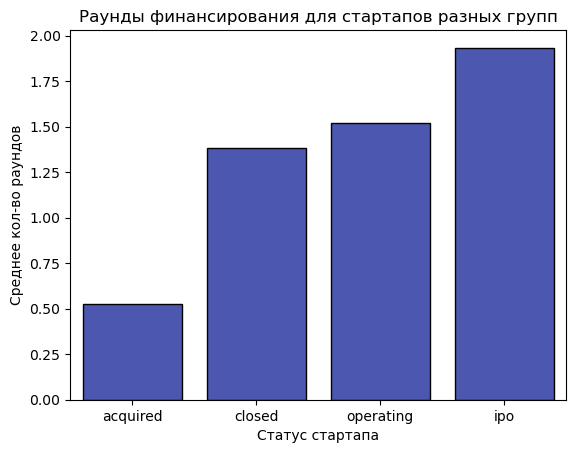

In [128]:
sns.barplot (data = status_rounds, x = 'status', y = 'mean', 
             color = '#3b4cc0', edgecolor = 'k')
plt.title('Раунды финансирования для стартапов разных групп')
plt.xlabel('Статус стартапа')
plt.ylabel('Среднее кол-во раундов')


Среднее количество раундов финансирования для стартапов, которые были куплены другой компанией (`acquired`) составило 0.53. Это говорит о том, что среди купленных стартапов, большое количество компаний, для которых вообще не указано дополнительное финансирование. Самое большое количество раундов финансирования  в среднем (1.93) получали стартапы, которые достигли уровня выхода на IPO, то есть развились до крупной компании. Компании, которые в итоге закрылись в среднем проходили больше одного раунда инвестирования (1.38),развивающиеся стартапы, достигнувшие статуса  `operating` в среднем продержались больше раундов инвестиций, чем закрытые компании, но меньше, чем крупные стартапы, достигнувшие размещения на IPO. 


## Итоговый вывод и рекомендации


По результатам анализа датасета с финансированием компаний можно сделать следующие выводы:
- Распределение инвестиций среди компаний имеет сильный разброс. Большинство стартапов получают небольшие суммы финансирования до 500 тыс. у.е., однако есть компании, которые привлекают огромные инвестиции, более 1 млрд. у.е. Это создаёт сильную асимметрию в данных и стандартные описательные статистики стоит применять не сразу ко всему датасету, а предварительно разбив данные на интересующие категории.
- Многие успешные стартапы (в том числе купленные) развиваются без значительного привлечения внешних инвестиций. Компании, достигшие IPO, как правило, проходят больше раундов финансирования.
- Даже привлечение нескольких раундов финансирования не гарантирует успех стартапа: закрытые компании в среднем проходили больше этапов финансирования, чем компании, которые были куплены.

- Стоимость покупки стартапов также сильно варьируется, и категория компании не является определяющим фактором.
По-видимому, основным определяющим фактором стоимости стартапа или объема инвестиций в него является не его категория, а продукт, команда и перспективность развития по сравнению с другими компаниями своей категории.

- Категории с наибольшим разбросом в стоимости стартапа, которые потенциально могут быть наиболее привлектельны для крупных инвесторов: `enterprise`, `public_relations`, `biotech` и `games_video`. Биотехнологические компании в среднем уступают в стоимости продажи только компаниям из категории `manufacturing`.


